##Loan Approval Prediction

The objective of this project is to predict whether a loan application would be approved by the bank, by analyzing an applicant's information which includes loan amount, tenure, cibil score, education, assests and other credit-related variables. Through this project, we can analyze the factors that affect the loan approval and also predict the loan approval status for a new applicant. This will further help in providing priority services to the customers who are more likely to get their loan approved.

### About the Dataset

The loan approval dataset is a collection of financial records and associated information used to determine the eligibility of individuals or organizations for obtaining loans from a lending institution. It includes various factors such as cibil score, income, employment status, loan term, loan amount, assets value, and loan status. This dataset is commonly used in machine learning and data analysis to develop models and algorithms that predict the likelihood of loan approval based on the given features.

### Data Dictionary
| Variable | Description |
| --- | --- |
|loan_id | Unique loan ID|
|no_of_dependents | Number of dependents of the applicant|
|education | Education level of the applicant|
|self_employed | If the applicant is self-employed or not|
|income_annum | Annual income of the applicant|
|loan_amount | Loan amount requested by the applicant|
|loan_tenure | Tenure of the loan requested by the applicant (in Years)|
|cibil_score | CIBIL score of the applicant|
|residential_asset_value | Value of the residential asset of the applicant|
|commercial_asset_value | Value of the commercial asset of the applicant|
|luxury_asset_value | Value of the luxury asset of the applicant|
|bank_assets_value | Value of the bank asset of the applicant|
|loan_status | Status of the loan (Approved/Rejected)|

###Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# Model evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
import os

# Create a 'plots' directory if it doesn't exist
plots_dir = 'plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

###Load the dataset

In [3]:
df = pd.read_csv("loan_approval_dataset.csv")

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.shape

(4269, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


The dataset contains demographic, financial, and credit-related variables relevant to loan approval decisions. Both numerical and categorical features are present, making it suitable for supervised classification analysis.

###Data Preprocessing

In [7]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [9]:
# Drop loan_id as it has no predictive value
df.drop(columns=["loan_id"], inplace=True)

In [10]:
# Check for missing values
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [11]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


###Exploratory Data Analysis (EDA)

In [12]:
df["loan_status"].value_counts(normalize=True)

,proportion
loan_status,
Approved,0.62216
Rejected,0.37784


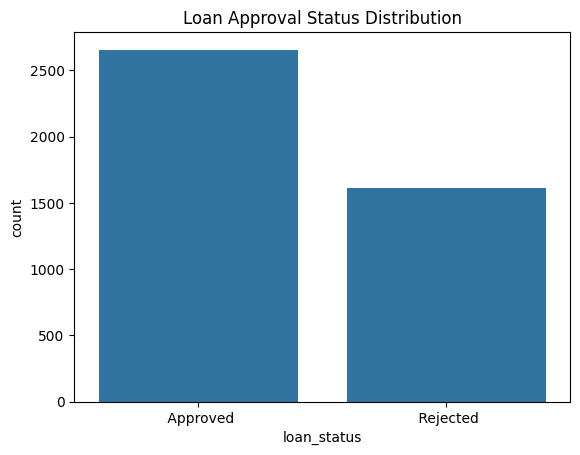

In [13]:
sns.countplot(x="loan_status", data=df)
plt.title("Loan Approval Status Distribution")
plt.savefig(os.path.join(plots_dir, 'loan_approval_status_distribution.png'))
plt.show()

The distribution of approved and rejected loans is reasonably balanced. This indicates that the dataset does not suffer from severe class imbalance and is suitable for classification modeling without additional resampling techniques.

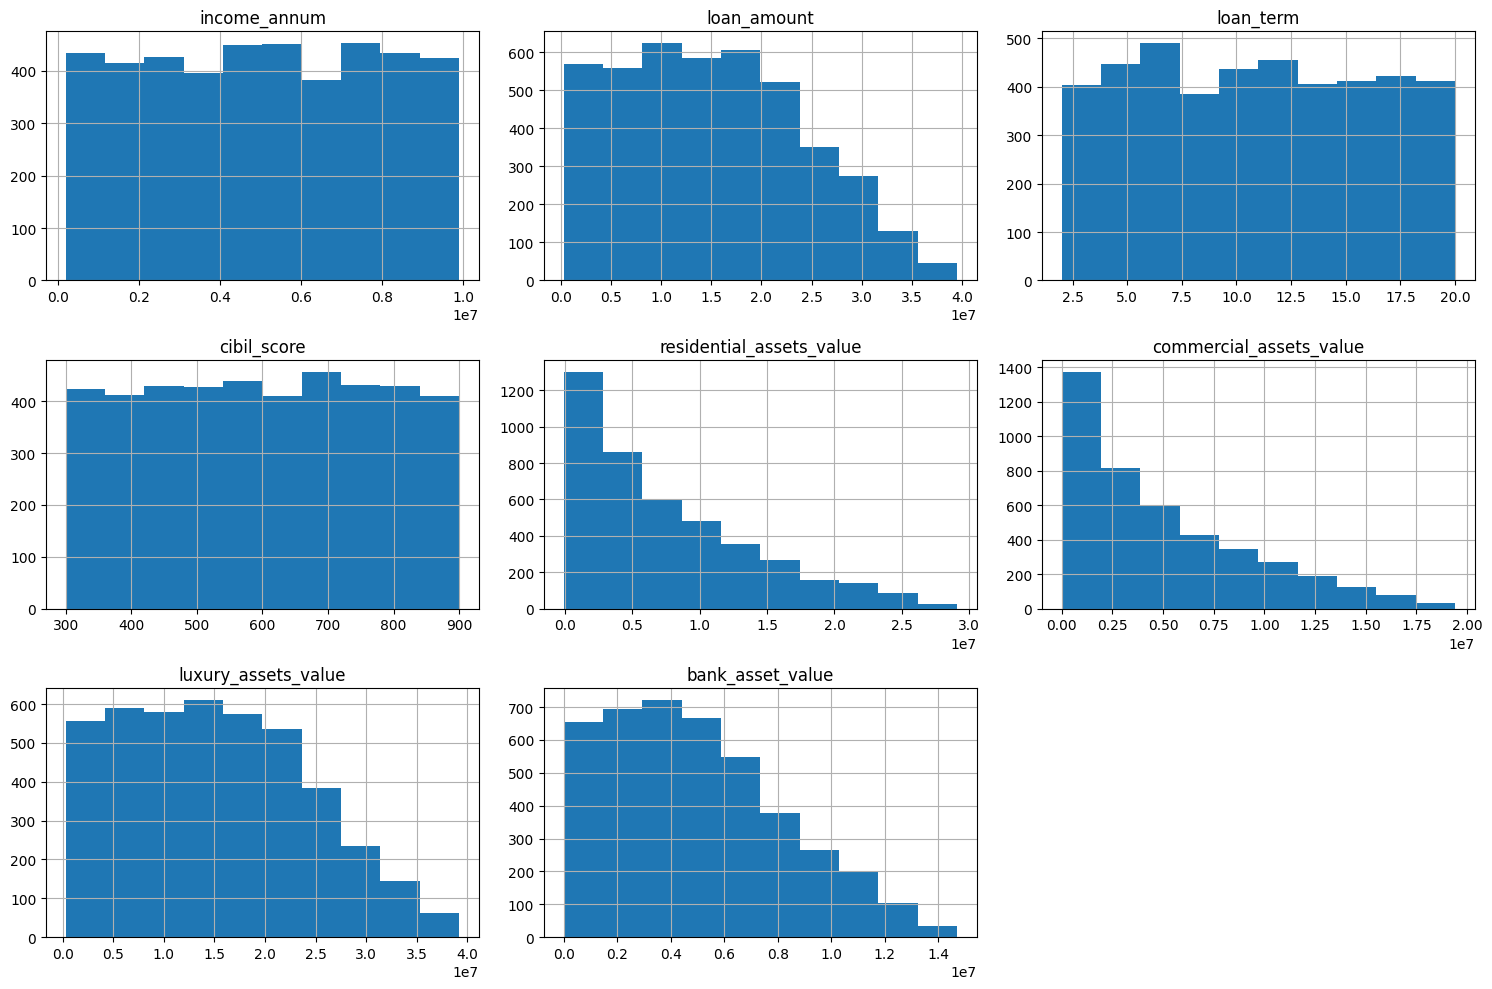

In [14]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df[numerical_cols[1:]].hist(figsize=(15, 10))
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'numerical_columns_histograms.png'))
plt.show()

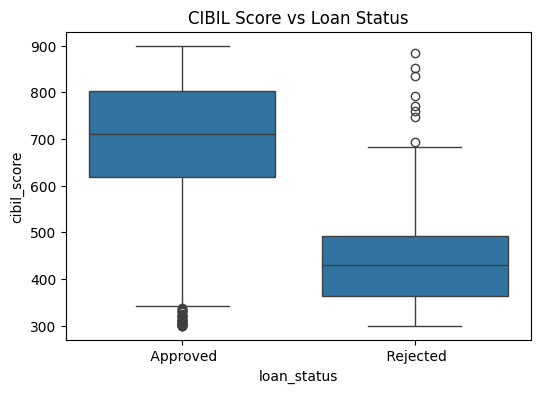

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x="loan_status", y="cibil_score", data=df)
plt.title("CIBIL Score vs Loan Status")
plt.savefig(os.path.join(plots_dir, 'cibil_score_vs_loan_status.png'))
plt.show()

Applicants with higher CIBIL scores show a significantly higher likelihood of loan approval. This highlights credit score as one of the most influential variables in the loan approval process.

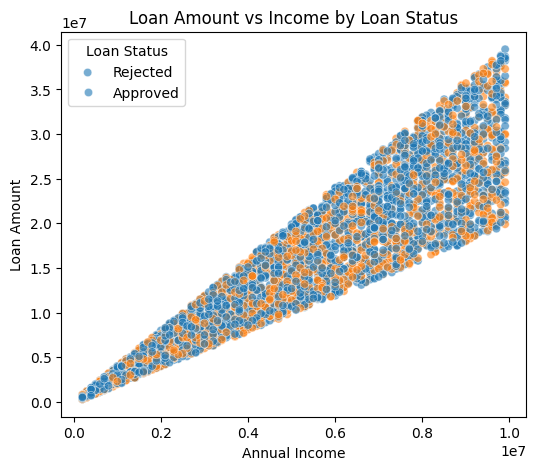

In [16]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="income_annum",
    y="loan_amount",
    hue="loan_status",
    data=df,
    alpha=0.6
)
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Loan Amount vs Income by Loan Status")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])
plt.savefig(os.path.join(plots_dir, 'loan_amount_vs_income_by_loan_status.png'))
plt.show()

While loan amount increases with income, substantial overlap between approved and rejected cases indicates that approval decisions depend on multiple interacting factors rather than income or loan amount alone.

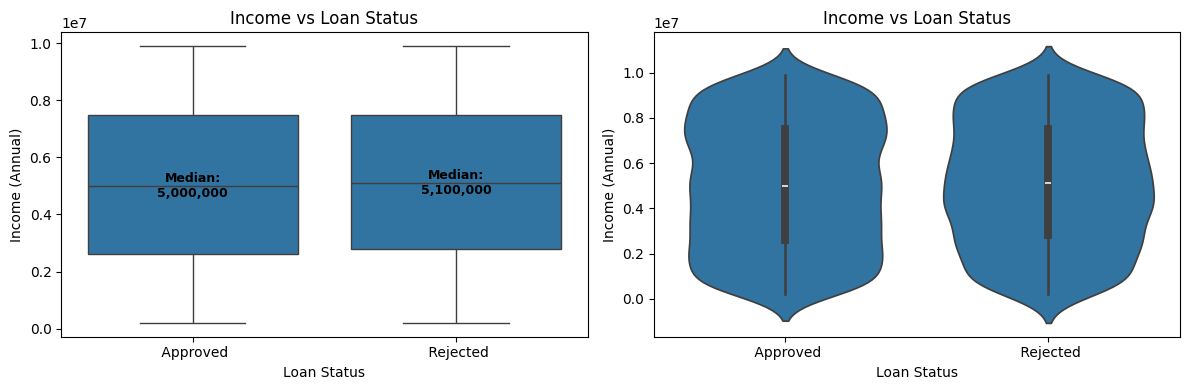

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
sns.boxplot(
    x="loan_status",
    y="income_annum",
    data=df,
    ax=axes[0]
)
axes[0].set_title("Income vs Loan Status")
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Income (Annual)")

# Calculate medians
medians = df.groupby("loan_status")["income_annum"].median()

# Add median labels
for i, median in enumerate(medians):
    axes[0].text(
        i,
        median,
        f"Median:\n{median:,.0f}",
        ha="center",
        va="center",
        fontsize=9,
        color="black",
        fontweight="bold"
    )

# Violin plot
sns.violinplot(
    x="loan_status",
    y="income_annum",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Income vs Loan Status")
axes[1].set_xlabel("Loan Status")
axes[1].set_ylabel("Income (Annual)")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'income_vs_loan_status_box_violin.png'))
plt.show()

The box plot indicates that the median income of rejected applicants is marginally higher than that of approved applicants. However, the violin plot reveals that approved loans exhibit a higher concentration of applicants in the mid-to-high income range, whereas rejected loans show greater variability across income levels. This suggests that income alone does not determine loan approval and must be assessed alongside credit score, asset ownership, and loan characteristics.

Overall, the exploratory analysis highlights that loan approval decisions depend on a combination of income, asset ownership, and loan characteristics rather than any single variable. The presence of overlap across applicant profiles reinforces the need for multi-factor assessment.

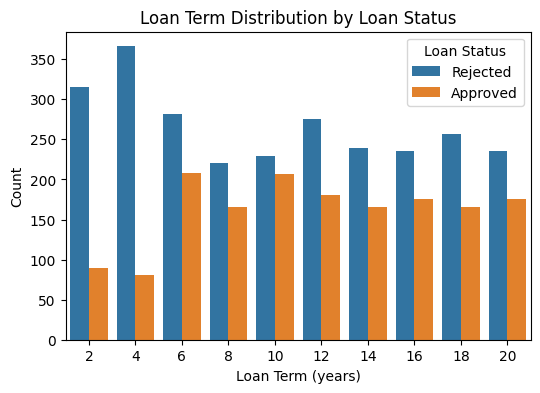

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="loan_term",
    hue="loan_status",
    data=df
)
plt.xlabel("Loan Term (years)")
plt.ylabel("Count")
plt.title("Loan Term Distribution by Loan Status")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])
plt.savefig(os.path.join(plots_dir, 'loan_term_distribution_by_status.png'))
plt.show()

Loan term influences approval decisions by reflecting repayment horizon risk, with moderate tenures showing higher approval likelihood compared to very short or extended durations.

###Feature Engineering & Encoding

In [19]:
# Encode education
df["education"] = df["education"].str.strip().map({
    "Graduate": 1,
    "Not Graduate": 0
})

# Encode self_employed
df["self_employed"] = df["self_employed"].str.strip().map({
    "Yes": 1,
    "No": 0
})

# Encode target variable
df["loan_status"] = df["loan_status"].str.strip().map({
    "Approved": 1,
    "Rejected": 0
})

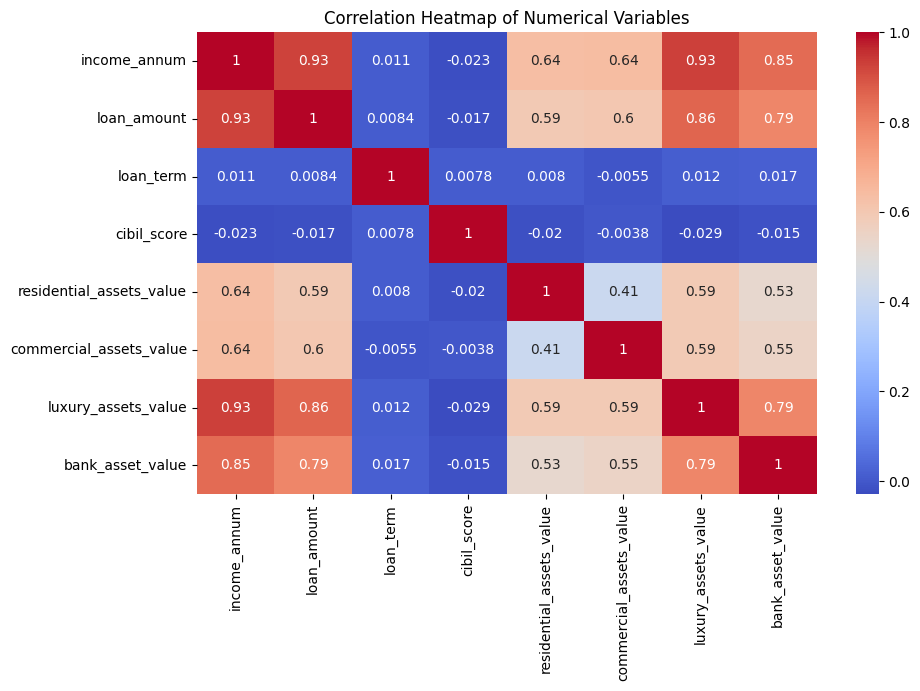

In [20]:
plt.figure(figsize=(10,6))
corr = df[numerical_cols[1:]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap_numerical_variables.png'))
plt.show()

The correlation heatmap indicates moderate positive relationships between income, asset-related variables, and loan approval status. Variables such as income and asset values are positively correlated with creditworthiness indicators, supporting their relevance in loan approval decisions. No extremely high correlations are observed among predictor variables, suggesting a low risk of multicollinearity in the dataset.

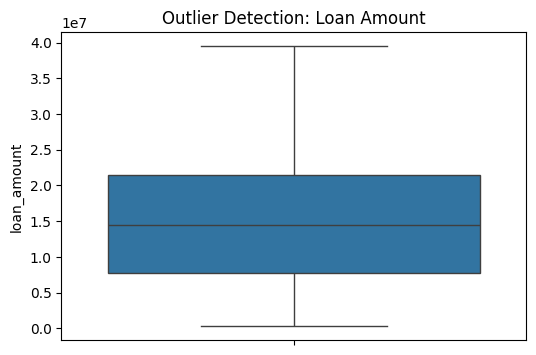

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["loan_amount"])
plt.title("Outlier Detection: Loan Amount")
plt.savefig(os.path.join(plots_dir, 'outlier_detection_loan_amount.png'))
plt.show()

The box plot indicates a wide spread in loan amounts, reflecting the presence of both small and high-value loan applications. While some extreme values are observed, these are likely legitimate high-value loans rather than data anomalies. Therefore, no outlier removal was performed to avoid eliminating meaningful financial observations.

In [22]:
df["total_assets"] = (
    df["residential_assets_value"] +
    df["commercial_assets_value"] +
    df["luxury_assets_value"] +
    df["bank_asset_value"]
)

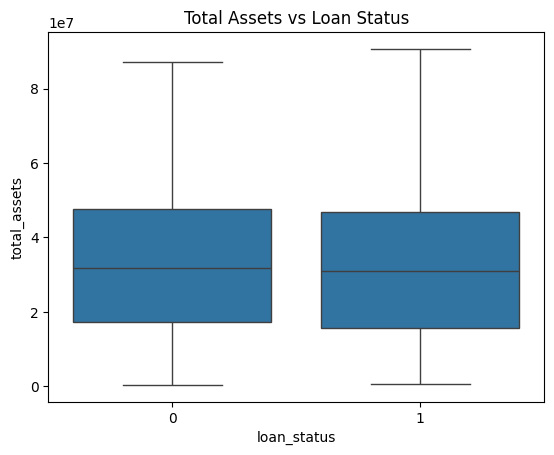

In [23]:
sns.boxplot(x="loan_status", y="total_assets", data=df)
plt.title("Total Assets vs Loan Status")
plt.savefig(os.path.join(plots_dir, 'total_assets_vs_loan_status.png'))
plt.show()

The box plot suggests that total asset values are broadly similar across approved and rejected loan applicants, with comparable median levels. However, approved applicants display a slightly higher upper range of asset values, indicating that higher asset ownership may support loan approval in certain cases. This further suggests that asset strength alone does not determine approval but contributes alongside other factors.

In [24]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###Feature Scaling (for Logistic Regression)

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Logistic Regression (Primary Model)

In [27]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [28]:
# Make predictions on the scaled test data
y_pred_log = log_model.predict(X_test_scaled)

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9133489461358314

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



The Logistic Regression model demonstrates strong predictive performance on the test dataset. Its stable accuracy and interpretable nature make it suitable for real-world loan approval decision support.

In [30]:
y_pred_log_train = log_model.predict(X_train_scaled)
y_pred_log_test = log_model.predict(X_test_scaled)

print("LR Training Accuracy:", accuracy_score(y_train, y_pred_log_train))
print("LR Test Accuracy:", accuracy_score(y_test, y_pred_log_test))

LR Training Accuracy: 0.9183016105417277
LR Test Accuracy: 0.9133489461358314


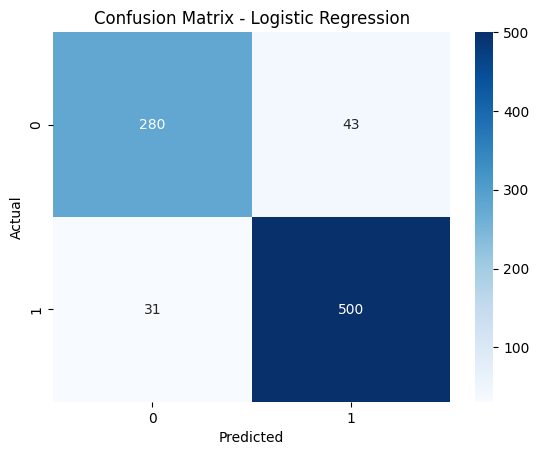

In [31]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(plots_dir, 'confusion_matrix_logistic_regression.png'))
plt.show()

The Logistic Regression model demonstrates strong classification performance, correctly identifying a large proportion of both approved and rejected loan applications. The relatively low number of false positives and false negatives indicates a balanced trade-off between approving eligible applicants and minimizing incorrect approvals. This makes the model suitable for supporting loan approval decisions in a risk-sensitive business context.

In [32]:
y_prob_lr = log_model.predict_proba(X_test_scaled)[:, 1]

###Decision Tree Classifier (Comparative Model)

In [33]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Pre-pruning is performed to reduce the risk of overfitting.

In [34]:
y_pred_dt = dt_model.predict(X_test)

In [35]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9718969555035128

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       323
           1       0.98      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



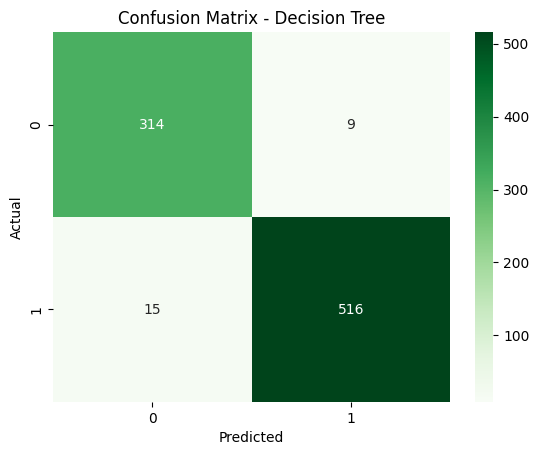

In [36]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(plots_dir, 'confusion_matrix_decision_tree.png'))
plt.show()

In [37]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [38]:
feature_importance2 = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance2

,Feature,Importance
6,cibil_score,0.873005
5,loan_term,0.090045
4,loan_amount,0.023144
3,income_annum,0.010576
7,residential_assets_value,0.001640
11,total_assets,0.001326
8,commercial_assets_value,0.000266
0,no_of_dependents,0.000000
2,self_employed,0.000000
1,education,0.000000


The Decision Tree model exhibits very high predictive accuracy, with minimal misclassifications across both approved and rejected loan categories. The low number of false positives indicates effective identification of risky applicants, while the small number of false negatives suggests limited loss of potentially eligible customers. The model serves as a decision-support system that assists banks in screening loan applications consistently and efficiently. By learning from historical approval patterns, it helps identify high-risk applicants early while highlighting eligible borrowers. This reduces manual effort, improves approval consistency, and supports better risk management.

###Overfitting Detection

In [39]:
# Training accuracy
x_pred_dt = dt_model.predict(X_train)
train_accuracy = accuracy_score(y_train, x_pred_dt)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred_dt)

print("DT Training Accuracy:", train_accuracy)
print("DT Test Accuracy:", test_accuracy)

DT Training Accuracy: 0.9742313323572475
DT Test Accuracy: 0.9718969555035128


The Decision Tree model shows comparable performance on both training and test datasets, indicating good generalization. Although decision trees are generally prone to overfitting, model diagnostics suggest this was effectively controlled.

###Random Forest Classifier (Comparative Model)

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=20, n_estimators=200, random_state=42)

In [41]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [42]:
print("RF Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("RF Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

RF Training Accuracy: 0.9677891654465594
RF Testing Accuracy: 0.9707259953161592


In [43]:
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred_rf))


Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       323
           1       0.99      0.96      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



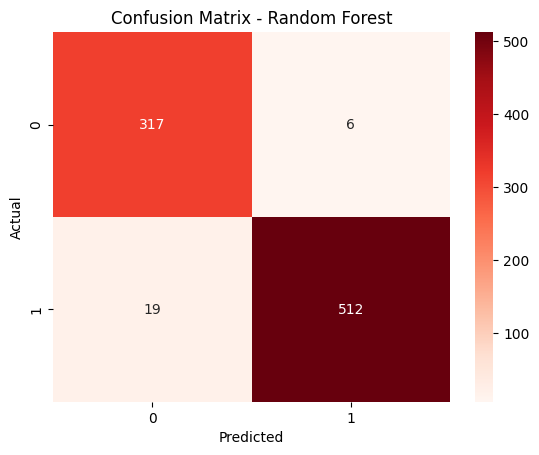

In [44]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(os.path.join(plots_dir, 'confusion_matrix_random_forest.png'))
plt.show()

In [45]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [46]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,cibil_score,0.892234
5,loan_term,0.048283
4,loan_amount,0.015285
11,total_assets,0.007893
8,commercial_assets_value,0.007281
9,luxury_assets_value,0.006928
3,income_annum,0.006709
7,residential_assets_value,0.005782
10,bank_asset_value,0.005210
0,no_of_dependents,0.002796


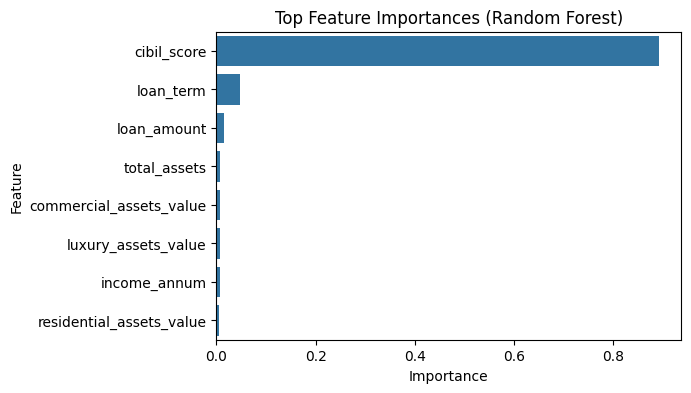

In [47]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(8)
)
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(os.path.join(plots_dir, 'top_feature_importances_random_forest.png'))
plt.show()

Random Forest feature importance confirms the central role of credit score while integrating supplementary financial indicators, resulting in more robust and balanced decision-making.

PR-AUC Scores

In [48]:
pr_auc_lr = average_precision_score(y_test, y_prob_lr)
pr_auc_dt = average_precision_score(y_test, y_prob_dt)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("PR-AUC Scores:")
print(f"Logistic Regression: {pr_auc_lr:.4f}")
print(f"Decision Tree: {pr_auc_dt:.4f}")
print(f"Random Forest: {pr_auc_rf:.4f}")

PR-AUC Scores:
Logistic Regression: 0.9847
Decision Tree: 0.9920
Random Forest: 0.9987


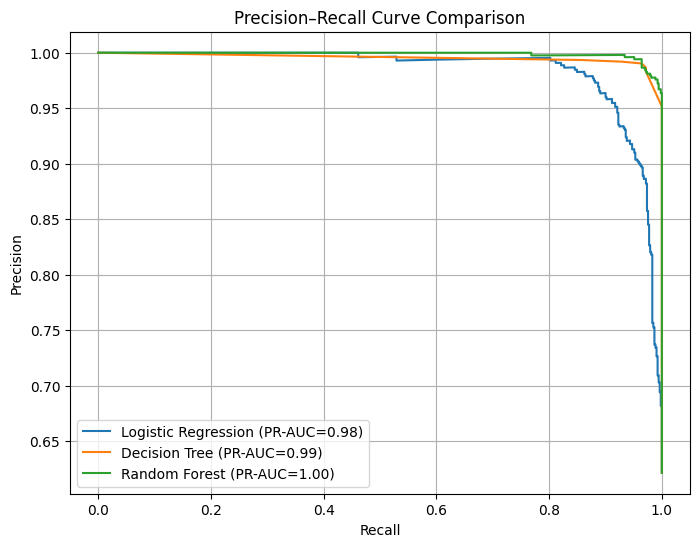

In [49]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (PR-AUC={pr_auc_lr:.2f})")
plt.plot(recall_dt, precision_dt, label=f"Decision Tree (PR-AUC={pr_auc_dt:.2f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (PR-AUC={pr_auc_rf:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, 'precision_recall_curve_comparison.png'))
plt.show()

In [50]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_test_pred_rf)
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.913349
1,Decision Tree,0.971897
2,Random Forest,0.970726
